# Insets and Zoom Axes

A single sky frame can only show one scale at a time. But some figures may
need *two* scales in view at once: the wide view that gives context, and the
close-up that shows the detail. Insets are how you put both in one figure — a
small second axes that zooms into a region of the main one, tied back to it
with a marked box and connector lines so the reader instantly sees *what* is
being magnified and *where* it lives.

This tutorial is about that machinery, and it answers the two questions inset
figures raise — **"how do I show this region up close?"** and **"how do I
adjust it?"** We'll cover typical zoom inset usage, the marker and connectors
that anchor it, where to place it (including a whole row of survey-style
cutouts), circular insets on globes and all-sky maps, the *inverse* move (a
small overview map that says "you are here"), and finally the lightweight
orientation indicator for when all you need is "which way is north?"

> **Scope:** this tutorial owns *inset axes and zoom/overview panels*. The
> measurement and furniture tools that often sit on a zoomed figure — beams, scale
> bars, a compass rose, rulers, reticles — live in **Annotations and Overlays**;
> the image-display deep-dive (stretches, colorbars, contours) is **FITS Images
> and Quicklook**.

## Contents

1. [The zoom inset in one call](#1.-The-zoom-inset-in-one-call)
2. [Marking the region and drawing connectors](#2.-Marking-the-region-and-drawing-connectors)
3. [Placing the inset](#3.-Placing-the-inset)
4. [Circular insets on globes and all-sky maps](#4.-Circular-insets-on-globes-and-all-sky-maps)
5. [Overview and locator insets](#5.-Overview-and-locator-insets)
6. [Orientation indicators](#6.-Orientation-indicators)
7. [Putting it together](#7.-Putting-it-together)
8. [Where to go next](#8.-Where-to-go-next)

In [1]:
import warnings

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from astropy.table import Table
from astropy.visualization import simple_norm
from astropy.visualization.wcsaxes.frame import EllipticalFrame
from astropy.wcs import WCS, FITSFixedWarning
from matplotlib.lines import Line2D

import skyplothelper as sph

warnings.simplefilter("ignore", FITSFixedWarning)

# A quiet, cohesive look for every figure. `set_style` applies its layers
# independently, so setting only the structural *base* here leaves the theme and
# palette layers free to come from whatever style is already active.
sph.set_style(base="structural")

DATA = "../../examples/data"

We reuse a few recurring **data anchors** so the focus stays on the insets, not on
wrangling data:

- the **Virgo cluster** slice of the Messier catalog — a real, recognizable knot
  of galaxies for typical "wide field + zoom" figures;
- the **NOIRLab all-sky panorama** of the Milky Way, for circular insets on
  all-sky maps and for the "you are here" overview;
- a small **synthetic cluster** for the placement demos, where a dense compact
  group is a blur in the wide view and resolves in the zoom;
- the **M51** optical image, for a real image close-up.

Everything below works the same on *your* table of `(ra, dec)` or your own FITS
image — substitute and the calls are unchanged.

In [2]:
# Anchor A — the Virgo cluster galaxies from the bundled Messier catalog.
messier = Table.read(f"{DATA}/messier.csv", format="ascii.csv")
virgo = messier[(messier["ra_deg"] > 180) & (messier["ra_deg"] < 195)
                & (messier["dec_deg"] > 2) & (messier["dec_deg"] < 20)]
VIRGO_CENTER = (187.5, 11.0)          # a wide field over the cluster
CHAIN_CENTER = (186.7, 12.9)          # Markarian's Chain — the zoom target

# Anchor B — the NOIRLab Milky Way panorama. It's an equirectangular galactic
# image with the galactic center at mid-image, so load it with frame="galactic"
# AND center=0 — the `center=` longitude must match the image layout, or every
# reprojected background comes out shifted by half the sky.
panorama, pano_hdr = sph.load_sky_image(
    f"{DATA}/Allsky_noirlab2430b_1280x640.jpg", frame="galactic", center=0)

# Anchor C — a synthetic field: a uniform background plus one dense compact cluster.
rng = np.random.default_rng(8)
FIELD_CENTER = (150.0, 20.0)
n_bg = 350
bg_ra = FIELD_CENTER[0] + rng.uniform(-6, 6, n_bg) / np.cos(np.radians(FIELD_CENTER[1]))
bg_dec = FIELD_CENTER[1] + rng.uniform(-5, 5, n_bg)
KNOT = (152.2, 22.2)
n_knot = 140
knot_ra = KNOT[0] + rng.normal(0, 0.22, n_knot) / np.cos(np.radians(KNOT[1]))
knot_dec = KNOT[1] + rng.normal(0, 0.22, n_knot)
synth = {
    "ra": np.concatenate([bg_ra, knot_ra]),
    "dec": np.concatenate([bg_dec, knot_dec]),
}

def clean_inset(ax, ticklabels=True):
    """Tidy an inset frame: drop the verbose `pos.eq.ra`/`pos.eq.dec` axis
    labels (the tick values already convey the scale), keeping the tick labels
    themselves so the reader can read off coordinates. Pass ``ticklabels=False``
    to hide those too (e.g. the schematic connector panels in §2)."""
    for c in (0, 1):
        ax.coords[c].axislabels.set_visible(False)
        if not ticklabels:
            ax.coords[c].set_ticklabel_visible(False)


def _dark_mode():
    """True when the active style is a dark theme — detected from the figure
    background luminance, so the notebook's colors adapt to whatever theme is
    in effect."""
    from matplotlib.colors import to_rgb
    r, g, b = to_rgb(mpl.rcParams["figure.facecolor"])
    return 0.299 * r + 0.587 * g + 0.114 * b < 0.5


def theme_palette():
    """The annotation palette matching the active light/dark theme — its role
    keys (`accent`, `accent2`, `ax_bg`, …) give colors that stay on-theme in
    either mode."""
    return sph.ANNOTATION_PALETTES["dark" if _dark_mode() else "publication"]


def card_color():
    """The theme-matched opaque inset-card color — the active palette's `ax_bg`
    (white in light mode, a dark card in dark mode). Pass it to
    `reproject_inset_axes(bg_color=...)` for a frame-shaped opaque background
    that holds up even when a figure is saved with a transparent background."""
    return theme_palette()["ax_bg"]


def inlay_colors():
    """(foreground, background) for `add_axis_inlay` that read in either mode —
    dark arrows on a light card in light mode, light arrows on a dark card in
    dark mode (a plain white card glares against a dark background)."""
    return ("0.92", "#20242c") if _dark_mode() else ("k", "white")


def in_window(cat, center, half_deg):
    """Rows of a Messier-style table within a square sky window (RA scaled by
    cos(dec)) — used to label only the sources a zoom inset actually shows."""
    dra = (cat["ra_deg"] - center[0]) * np.cos(np.radians(center[1]))
    ddec = cat["dec_deg"] - center[1]
    return cat[(np.abs(dra) < half_deg) & (np.abs(ddec) < half_deg)]


# Colors for the region-of-interest (ROI) markers and connectors. Over catalog
# fields, the theme palette's `accent` (brick red in light mode, gold in dark)
# keeps the ROI on-theme yet high-contrast. Over the dark Milky Way imagery —
# which is dark in *either* mode — a fixed warm amber reads best.
ROI = theme_palette()["accent"]
ROI_WARM = "#F5B301"

# The Markarian's Chain galaxies inside the zoom window — the ones to label.
chain = in_window(virgo, CHAIN_CENTER, 1.3)

Here is where we're headed — the common usage this whole tutorial is about. A
real image, the M51 "Whirlpool" galaxy, shown wide for context with a zoom inset
on its bright nucleus: marked and connected so the eye follows straight from the
whole galaxy to the detail. Everything below builds up to figures like this.

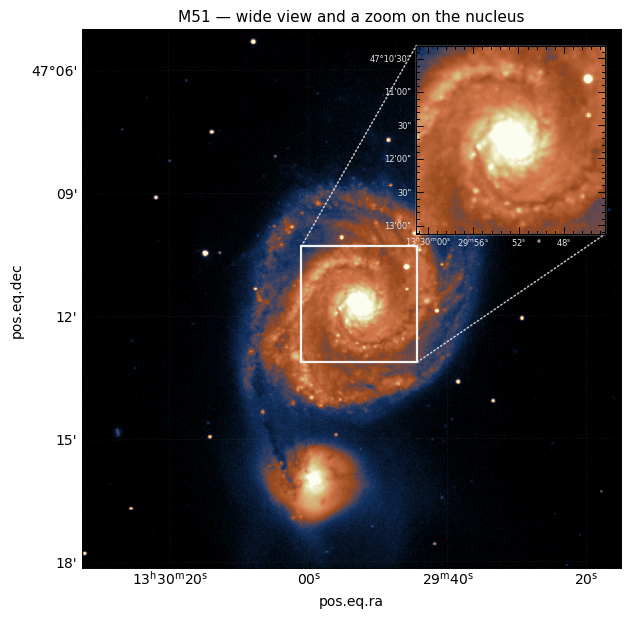

In [3]:
# fig-slug: overview
m51 = fits.open(f"{DATA}/m51_optical.fits")[0]
m51_data = m51.data.astype(float)
m51_wcs = WCS(m51.header)
m51_norm = simple_norm(m51_data, "asinh", percent=99.6)
M51_NUCLEUS = (202.4696, 47.1953)

fig = plt.figure(figsize=(8.5, 7))
ax = fig.add_subplot(111, projection=m51_wcs)
ax.imshow(m51_data, origin="lower", cmap="sph.deepsky", norm=m51_norm)
ax.coords.grid(color="0.6", alpha=0.2, lw=0.5)
ax.set_title("M51 — wide view and a zoom on the nucleus", fontsize=11)

# When the inset is a zoom of the *same* image, share the parent's WCS and simply
# crop it — pass `wcs=` and set the pixel window, no reprojection needed.
inset = sph.reproject_inset_axes(
    ax, rect=[0.62, 0.62, 0.35, 0.35], transform="parent", wcs=m51_wcs,
    bg_color="k")   # opaque black canvas behind the image
inset.imshow(m51_data, origin="lower", cmap="sph.deepsky", norm=m51_norm)
nx, ny = m51_wcs.wcs_world2pix([M51_NUCLEUS], 0)[0]
half = 55  # pixels — a ~0.06 deg window on the nucleus
inset.set_xlim(nx - half, nx + half)
inset.set_ylim(ny - half, ny + half)
clean_inset(inset)
for c in (0, 1):                      # light labels read over the dark image
    inset.coords[c].set_ticklabel(color="0.9")
# A light neutral for the box + connectors — it stays crisp over both the dark
# sky and the warm spiral arms of the colormapped image.
sph.mark_inset_axes(ax, inset, edgecolor="0.95", linewidth=1.6)
sph.connect_inset_axes(ax, inset, color="0.95", linewidth=1.1)
plt.show()

**Setting a view in degrees.** The inset window above was set in *pixels*
(`inset.set_xlim(nx - half, nx + half)`) because we already had the nucleus in
pixel coordinates. More often you'll want to name the region in **degrees** —
and since a frame's data coordinates are pixels, plain `set_xlim`/`set_ylim`
won't take them. Use the view helpers, which work on any WCS frame, parent or
inset:

```python
sph.set_extent(inset, [202.44, 202.50, 47.17, 47.22])  # an RA/Dec box, degrees
sph.zoom_to(ax, ra, dec, pad=1)                         # frame points, + margin
sph.set_view(ax, center=(202.47, 47.20), fov=0.12)      # center + angular width
```

These reframe the view in world coordinates. On a rectilinear map the box is
exact; on a curved projection `set_extent` frames the bounding region — see
[Globe & Planet Plotting](globe_plots.ipynb).

## 1. The zoom inset in one call

The workhorse is `reproject_inset_axes`. Give it the parent axes, a rectangle
to occupy, and the sky region to zoom (`center` + `size` in degrees), and it
returns a **fully live child `WCSAxes`** with its own WCS — reprojected into
whatever projection you ask for. That last point is the key idea: the inset is
not a cropped picture of the parent, it is a *real axes you draw into*, in
world coordinates, exactly like the main frame.

So the pattern is always two steps: **make the inset, then plot into it.** Here we
take a wide tangent-plane view of the Virgo cluster and lay two zooms of
Markarian's Chain over it — identical except for one setting — to surface a
subtlety worth knowing up front: **an inset's background isn't something to
ignore.** Depending on the theme (and on how the figure is exported) it can
come out opaque or transparent, so it's worth setting explicitly —
`facecolor='none'` for a see-through inset that lets the parent read through it
(top), or `bg_color=` for an opaque card that blocks it (bottom).

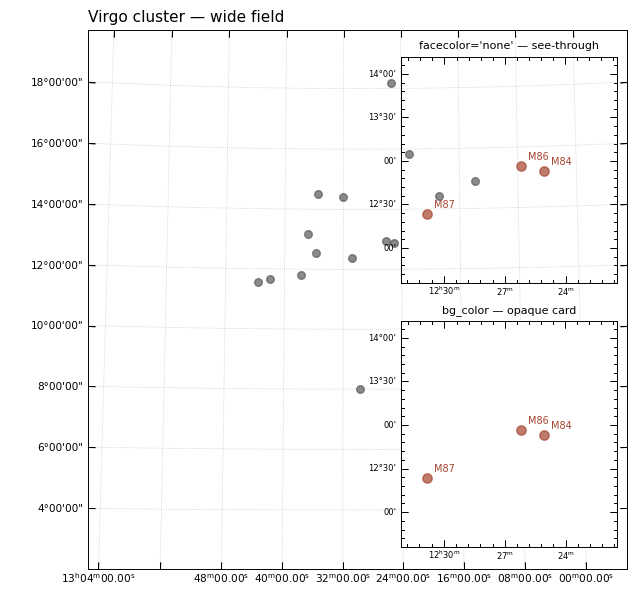

In [4]:
# fig-slug: zoom-one-call
fig = plt.figure(figsize=(8.5, 7))
ax = sph.make_wcs_frame(111, projection="TAN", center=VIRGO_CENTER, fov_deg=18, fig=fig)
sph.plot_catalog(ax, virgo, ra_col="ra_deg", dec_col="dec_deg", s=30, color="0.35")
ax.set_title("Virgo cluster — wide field", fontsize=11, loc="left")

# Two identical zooms laid over the parent (transform='parent' — more on that in
# §3) so the difference shows: `facecolor='none'` leaves the upper one see-through
# and the wide field reads straight through it, while `bg_color=` gives the lower
# one an opaque theme-matched card (`card_color()` returns the palette's `ax_bg`,
# see above) that blocks it.
common = dict(transform="parent", projection="TAN", center=CHAIN_CENTER, size=2.6)
see_through = sph.reproject_inset_axes(ax, rect=[0.58, 0.53, 0.40, 0.42],
                                       facecolor="none", **common)
filled = sph.reproject_inset_axes(ax, rect=[0.58, 0.04, 0.40, 0.42],
                                  bg_color=card_color(), **common)
for ins in (see_through, filled):
    # Step 2: plot into it — it's a normal WCSAxes, so the same call works. Label
    # only the galaxies inside the window so the names don't spill onto the wide view.
    sph.plot_catalog(ins, chain, ra_col="ra_deg", dec_col="dec_deg",
                     s=45, color=ROI, label_col="name", label_fontsize=7)
    clean_inset(ins)
see_through.set_title("facecolor='none' — see-through", fontsize=8)
filled.set_title("bg_color — opaque card", fontsize=8)
plt.show()

Each inset is its own frame with its own ticks in the zoomed scale, and both were
built with a single `reproject_inset_axes` call. A few knobs worth knowing:

- **`center` + `size`** define the sky region (`size` is degrees; a scalar means a
  square, a `(dx, dy)` tuple a rectangle).
- **`projection`** is the inset's own projection — `'TAN'` for a small-area zoom,
  `'SIN'` for a globe-style patch (§4). It need not match the parent.
- **`inherit_frame=True`** (default) copies the parent's coordinate frame, so a
  galactic parent gets a galactic inset; **`direction='inherit'`** matches the
  parent's east direction so the two never silently disagree on handedness.
- **`transform`** chooses how `rect` is read — figure fraction by default, or
  parent-axes fraction (§3).
- **`auto_fontsize=True`** (default) shrinks the inset's tick labels to suit its
  smaller size; pass `False` to keep the rcParams default.

> **Note — set the inset background explicitly.** An inset is drawn *after* the
> parent, on top of it, and its default background isn't guaranteed: a standard
> light session tends to give it an opaque patch in the page color, while a dark
> theme saved with a transparent background exports it see-through. Rather than
> rely on that, say what you want. **`facecolor='none'`** forces it see-through,
> so the parent (or page) reads through — good for a floating label inset.
> **`bg_color=`** paints a frame-shaped opaque card (here matched to the active
> theme) that holds up anywhere — the right choice whenever the inset sits over
> content. The rest of this tutorial gives its content insets a `bg_color`.

## 2. Marking the region and drawing connectors

A zoom inset floating in a corner doesn't, on its own, show *which* part of the
wide field it magnifies. Two helpers close that gap:

- `mark_inset_axes` draws the inset's region-of-interest (ROI) frame edges back
  onto the **parent**, following the parent's projection (so on a curved map the
  box comes out curved), so that the inset's extent can be seen on the parent
  frame;
- `connect_inset_axes` draws the connector lines from the ROI corners to the
  inset corners.

Add them after making the inset and the picture reads at a glance.

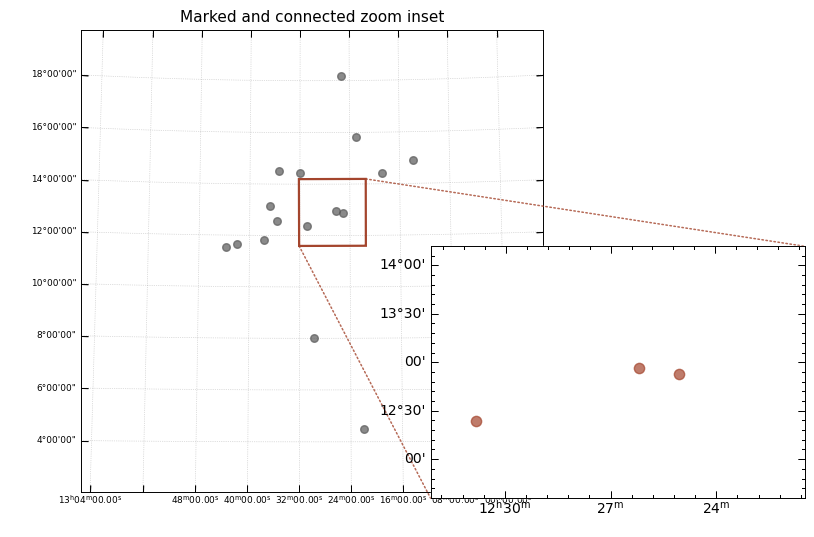

In [5]:
# fig-slug: mark-connect
fig = plt.figure(figsize=(11, 6))
ax = sph.make_wcs_frame(111, projection="TAN", center=VIRGO_CENTER, fov_deg=18, fig=fig)
sph.plot_catalog(ax, virgo, ra_col="ra_deg", dec_col="dec_deg", s=30, color="0.35")
ax.set_title("Marked and connected zoom inset", fontsize=11)

inset = sph.reproject_inset_axes(
    ax, rect=[0.62, 0.10, 0.34, 0.42], transform="figure",
    projection="TAN", center=CHAIN_CENTER, size=2.6, bg_color=card_color())
sph.plot_catalog(inset, chain, ra_col="ra_deg", dec_col="dec_deg", s=55, color=ROI)
clean_inset(inset)

sph.mark_inset_axes(ax, inset, edgecolor=ROI, linewidth=1.6)
sph.connect_inset_axes(ax, inset, color=ROI, linewidth=1.1)
plt.show()

**Adjusting the connectors.** Which corners the connectors link, and how they
bow, are the two controls you can set by hand. `connect_inset_axes` picks a
routing automatically, but you can name it:

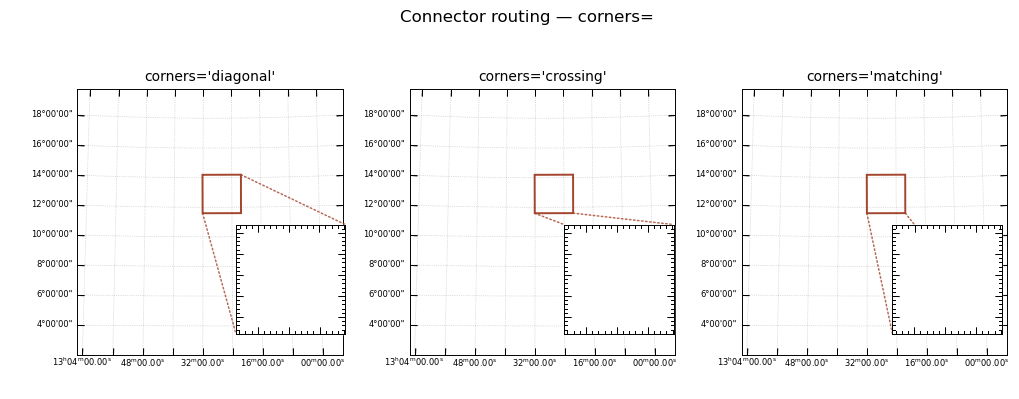

In [6]:
# fig-slug: connector-corners
fig = plt.figure(figsize=(12, 4.2))
for i, mode in enumerate(["diagonal", "crossing", "matching"]):
    a = sph.make_wcs_frame((1, 3, i + 1), projection="TAN",
                           center=VIRGO_CENTER, fov_deg=18, fig=fig)
    a.set_title(f"corners='{mode}'", fontsize=10)
    # Transparent inset on purpose here: these panels are about the connector
    # routing, not the inset content, so we let the empty frame stay see-through.
    ins = sph.reproject_inset_axes(
        a, rect=[0.58, 0.06, 0.40, 0.40], transform="parent",
        projection="TAN", center=CHAIN_CENTER, size=2.6)
    clean_inset(ins, ticklabels=False)
    sph.mark_inset_axes(a, ins, edgecolor=ROI, linewidth=1.4)
    sph.connect_inset_axes(a, ins, corners=mode, color=ROI, linewidth=1.1)
fig.suptitle("Connector routing — corners=", fontsize=12)
fig.subplots_adjust(top=0.84, wspace=0.25)
plt.show()

| `corners=` | What it does | Best for | Caveat |
| --- | --- | --- | --- |
| `'diagonal'` *(default)* | Links an axis-internal diagonal corner pair; connectors hug the outsides of both axes | The common off-to-a-corner placement | Degenerates for straight-side placements, and falls back to `'crossing'` |
| `'crossing'` | Near-edge to near-edge, forming a clean trapezoid (the classic mpl-toolkits look) | Inset directly beside / above / below | Connectors cross toward the near edge |
| `'matching'` | Same-named corner to same-named corner | When you want parallel same-side links | Connectors run *behind* the inset to its far edge |
| *list of pairs* | Explicit `[(parent, inset), …]`, e.g. `[('ur','ll'),('ll','ur')]` | Full manual control | You place every corner yourself |

For the shape of the lines themselves, **`curvature`** bows each connector into a
Bezier arc — positive flares them *outward* (away from the line of centers,
keeping the ROI interior clear), negative sweeps them *inward*. `0.0` is the
straight default; `0.2`–`0.4` is a soft-to-pronounced curve.

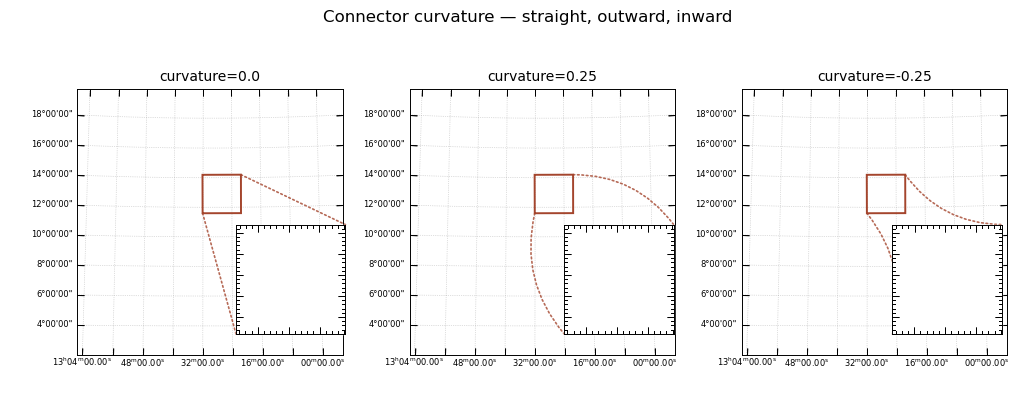

In [7]:
# fig-slug: connector-curvature
fig = plt.figure(figsize=(12, 4.2))
for i, curv in enumerate([0.0, 0.25, -0.25]):
    a = sph.make_wcs_frame((1, 3, i + 1), projection="TAN",
                           center=VIRGO_CENTER, fov_deg=18, fig=fig)
    a.set_title(f"curvature={curv}", fontsize=10)
    # Transparent inset on purpose (see the corner-routing panels above).
    ins = sph.reproject_inset_axes(
        a, rect=[0.58, 0.06, 0.40, 0.40], transform="parent",
        projection="TAN", center=CHAIN_CENTER, size=2.6)
    clean_inset(ins, ticklabels=False)
    sph.mark_inset_axes(a, ins, edgecolor=ROI, linewidth=1.4)
    sph.connect_inset_axes(a, ins, color=ROI, linewidth=1.2, curvature=curv)
fig.suptitle("Connector curvature — straight, outward, inward", fontsize=12)
fig.subplots_adjust(top=0.84, wspace=0.25)
plt.show()

## 3. Placing the inset

`rect` is `(left, bottom, width, height)`, and **`transform`** decides what those
fractions are measured against:

- `transform='figure'` (default) — fractions of the whole figure. Best when the
  inset sits *outside* the parent, in the figure margin.
- `transform='parent'` — fractions of the parent axes' box. Best for tucking the
  inset *inside* a corner of the parent, or straddling its edge.

The synthetic field below has a dense compact cluster that is just an unresolved
blur in the wide view. We drop the zoom **inside** the parent's upper-left corner,
where there's empty sky, so the figure stays compact — and the cluster resolves
into individual sources.

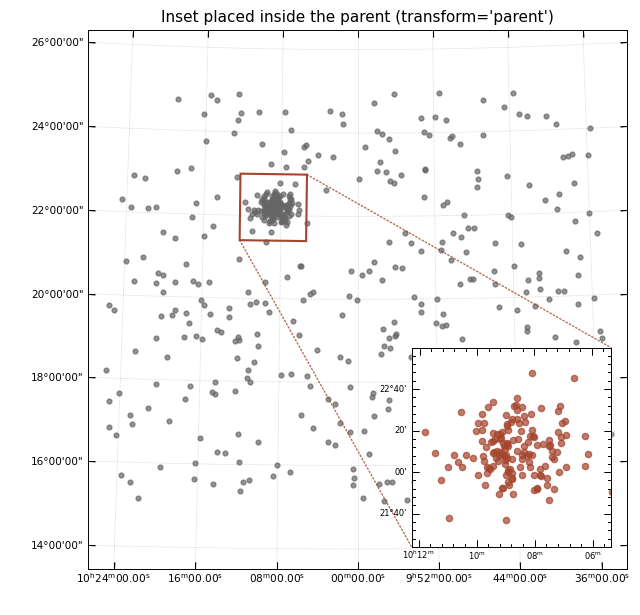

In [8]:
# fig-slug: placement
fig = plt.figure(figsize=(8.5, 7))
ax = sph.make_wcs_frame(111, projection="TAN", center=FIELD_CENTER, fov_deg=13, fig=fig)
sph.plot_catalog(ax, synth, s=12, color="0.4", alpha=0.7)
ax.set_title("Inset placed inside the parent (transform='parent')", fontsize=11)

# A parent-fraction rect tucks the inset into the lower-right corner (away from the
# cluster it magnifies, so the marker box and connectors stay clear); `bg_color`
# gives it an opaque theme-matched card that stands out over the field beneath.
inset = sph.reproject_inset_axes(
    ax, rect=[0.60, 0.04, 0.37, 0.37], transform="parent",
    projection="TAN", center=KNOT, size=1.6, bg_color=card_color())
sph.plot_catalog(inset, synth, s=20, color=ROI)
clean_inset(inset)

sph.mark_inset_axes(ax, inset, edgecolor=ROI, linewidth=1.5)
sph.connect_inset_axes(ax, inset, color=ROI, linewidth=1.0)
plt.show()

> **Tip:** when the inset overlaps the parent, connectors can run both *inside* and
> *outside* the inset frame — that's expected, and it reads correctly as long as
> the inset has an opaque background (via `bg_color=`). Use `facecolor='none'` to
> keep it see-through instead, letting the parent behind it show.

### A row of cutouts — several insets, one parent

Nothing limits a figure to a single zoom. The survey paper may benefit from a **row of
postage stamps** under one wide view: call `reproject_inset_axes` once per target,
mark and connect each, and lay the stamps side by side with figure-fraction
rects. Two habits keep a multi-cutout figure readable: **order the insets to
match their positions on the sky**, so no connector has to cross another, and
keep the marker color consistent from outline box to inset (or give each pair its own
color once a crowded layout needs the extra keying).

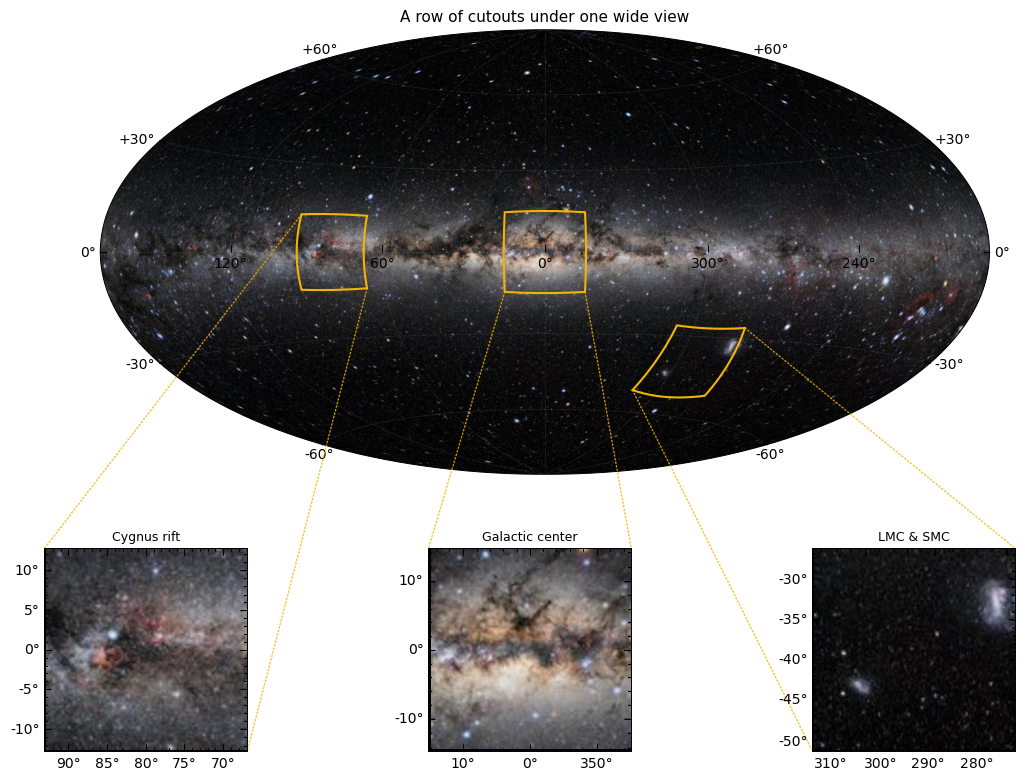

In [9]:
# fig-slug: postage-stamps
TARGETS = [("Cygnus rift", (80, 0), 26),        # (title, galactic center, size in deg)
           ("Galactic center", (0, 0), 30),
           ("LMC & SMC", (293, -40), 26)]

fig = plt.figure(figsize=(12, 7.8))
ax = sph.make_wcs_frame(111, projection="AIT", center=0, frame="galactic",
                        npix=(1200, 600), fig=fig)
fig.subplots_adjust(bottom=0.40, top=0.97)   # clear a band for the stamp row
ax.imshow(sph.reproject_background(panorama, pano_hdr, ax), origin="lower")
ax.set_title("A row of cutouts under one wide view", fontsize=11)

for (name, center, size), left in zip(TARGETS, (0.065, 0.385, 0.705)):
    stamp = sph.reproject_inset_axes(
        ax, rect=[left, 0.045, 0.23, 0.26], transform="figure",
        projection="TAN", center=center, size=size, bg_color="k")
    stamp.imshow(sph.reproject_background(panorama, pano_hdr, stamp),
                 origin="lower")
    stamp.set_title(name, fontsize=9)
    clean_inset(stamp)
    sph.mark_inset_axes(ax, stamp, edgecolor=ROI_WARM, linewidth=1.5)
    sph.connect_inset_axes(ax, stamp, color=ROI_WARM, linewidth=1.0)
plt.show()

Each stamp is a full `WCSAxes` in its own right — drop a beam, a scale bar, or
labels into any of them — and each marker box follows the parent's curvature:
the LMC & SMC box appears as a skewed trapezoid on the parent frame because
that's what a square patch of sky looks like there on an Aitoff map.

## 4. Circular insets on globes and all-sky maps

On a curved all-sky map or a globe, a rectangular inset can feel out of place — a
**circular** inset might read more naturally. Two pieces make it work:

- build the inset with `projection='SIN'` (orthographic) and
  `frame_class=EllipticalFrame`, which gives a round frame (the reprojector
  auto-sets `aspect='equal'` so it renders as a true circle);
- mark the ROI with `mark_inset_axes(style='circle', …)`, and let
  `connect_inset_axes` auto-detect the circular frame and draw the two **outer
  tangent** connectors instead of corner links.

Here the parent is the NOIRLab Milky Way panorama on an Aitoff all-sky map, and the
circular inset zooms the crowded galactic-center region — with the panorama
reprojected into *both* axes.

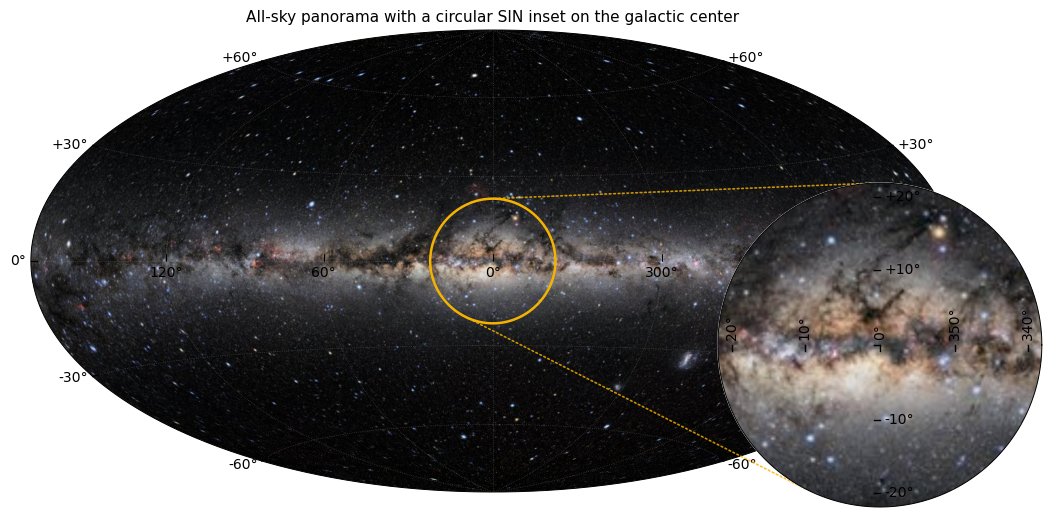

In [10]:
# fig-slug: circular-inset
fig = plt.figure(figsize=(12, 6))
ax = sph.make_wcs_frame(111, projection="AIT", center=0, frame="galactic",
                        npix=(1200, 600), fig=fig)
ax.imshow(sph.reproject_background(panorama, pano_hdr, ax), origin="lower")
ax.set_title("All-sky panorama with a circular SIN inset on the galactic center",
             fontsize=11)

inset = sph.reproject_inset_axes(
    ax, rect=[0.70, 0.08, 0.27, 0.55], transform="figure",
    projection="SIN", center=(0, 0), size=44, frame_class=EllipticalFrame)
inset.imshow(sph.reproject_background(panorama, pano_hdr, inset),
             origin="lower")
# A SIN inset gets clean in-frame coordinate labels automatically; recolor them
# light so they read over the bright galactic-center image.
for c in (0, 1):
    inset.coords[c].set_ticklabel(color="0.9")

sph.mark_inset_axes(ax, inset, style="circle", center=(0, 0), radius=22,
                    edgecolor=ROI_WARM, linewidth=1.8)
sph.connect_inset_axes(ax, inset, color=ROI_WARM, linewidth=1.2)
plt.show()

The `style='circle'` marker takes a sky **`center`** and angular **`radius`**, and
the connectors land exactly on the marker circle even where the all-sky projection
distorts it into an oval. `curvature` bows the tangent pair the same way it does
the rectangular connectors — useful when a soft flare reads better than straight
lines against a busy background.

## 5. Overview and locator insets

The inset doesn't have to *zoom in* — the inverse could be just as useful. When
your main figure is a tight field, a small **overview map** answers "where on
the sky is this?" The trick is to swap the roles: the *overview* is the
low-detail axes, and `mark_inset_axes` draws your **detailed field's** footprint
onto it — a "you are here" dot on the whole sky.

Below, the main axes is the Virgo close-up; a small orthographic globe in the
corner shows that patch's place on the celestial sphere, with the field marked.

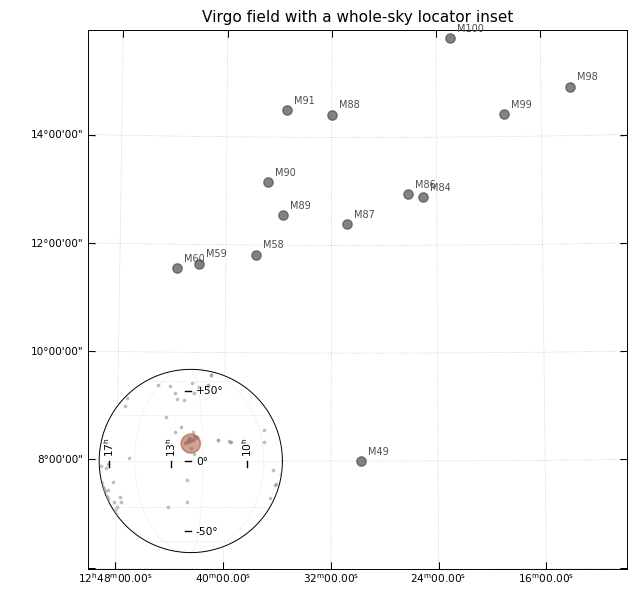

In [11]:
# fig-slug: locator
fig = plt.figure(figsize=(8.5, 7))
ax = sph.make_wcs_frame(111, projection="TAN", center=VIRGO_CENTER, fov_deg=10, fig=fig)
sph.plot_catalog(ax, virgo, ra_col="ra_deg", dec_col="dec_deg",
                 s=45, color="0.3", label_col="name", label_fontsize=7)
ax.set_title("Virgo field with a whole-sky locator inset", fontsize=11)

# The locator: an orthographic hemisphere centered near the field. Roles are
# reversed — it is the *parent* for marking purposes, so the field's ROI lands on it.
locator = sph.reproject_inset_axes(
    ax, rect=[0.02, 0.03, 0.34, 0.34], transform="parent",
    projection="SIN", center=(VIRGO_CENTER[0], 0), size=170,
    frame_class=EllipticalFrame, bg_color=card_color())
locator.coords.grid(color="0.6", alpha=0.4, lw=0.5)
sph.plot_catalog(locator, messier, ra_col="ra_deg", dec_col="dec_deg",
                 s=3, color="0.6", alpha=0.5)
# Mark the main field's footprint on the locator (locator plays "parent").
sph.mark_inset_axes(locator, ax, style="circle", center=VIRGO_CENTER, radius=6,
                    edgecolor=ROI, facecolor=ROI, alpha=0.5, linewidth=1.2)
plt.show()

> **Note:** because the ROI here is small relative to the whole-sky overview, a
> filled circle marker reads better than corner connectors — the eye goes straight
> to the dot. For a modest zoom (a few×), the marked-box-plus-connectors of §2 is
> clearer; for a *huge* ratio like this one, a labeled marker on the overview wins.

## 6. Orientation indicators

Sometimes you don't need a second axes at all — you just need to tell the reader
*which way is which*. `add_axis_inlay` draws a compact **orientation indicator** in
a corner: a small wireframe of the projection's outline with arrows showing the
longitude and latitude axis directions. It is a lightweight cue, **not** a content
inset — think of it as a coordinate compass.

It shines where the axis directions aren't obvious: a tilted globe, or a field
where you want to remind the reader that RA increases to the *left*.

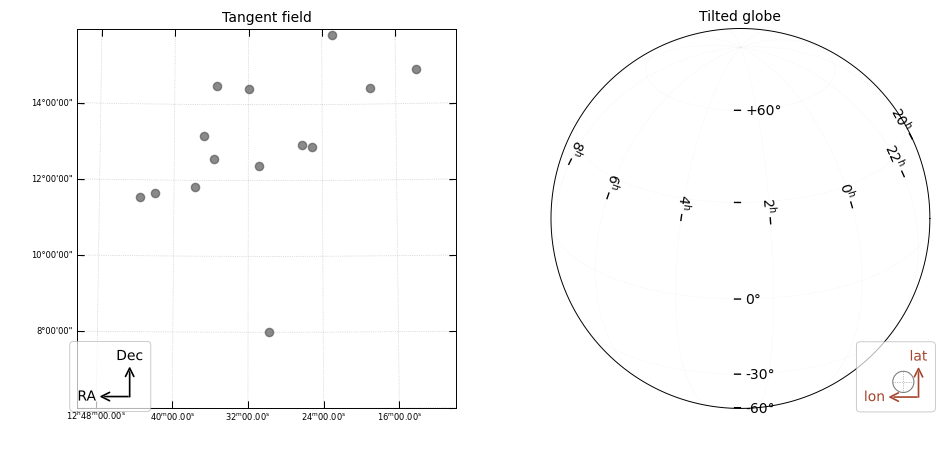

In [12]:
# fig-slug: orientation
fig = plt.figure(figsize=(11, 5.2))
# Theme-matched colors: dark arrows on a light card in light mode, light arrows
# on a dark card in dark mode (the default white card glares against a dark
# background).
fg, bg = inlay_colors()

a1 = sph.make_wcs_frame(121, projection="TAN", center=VIRGO_CENTER, fov_deg=10, fig=fig)
sph.plot_catalog(a1, virgo, ra_col="ra_deg", dec_col="dec_deg", s=35, color="0.35")
a1.set_title("Tangent field", fontsize=10)
sph.add_axis_inlay(a1, loc="lower left", lon_label="RA", lat_label="Dec",
                   color=fg, bg_color=bg)

a2 = sph.make_globe_frame(122, center_LONdeg=40, center_LATdeg=25, projection="SIN")
a2.set_title("Tilted globe", fontsize=10)
sph.add_axis_inlay(a2, loc="lower right", lon_label="lon", lat_label="lat",
                   color=ROI, bg_color=bg)

fig.subplots_adjust(wspace=0.25)
plt.show()

Useful knobs: **`loc`** (a corner name or an `(x, y)` axes-fraction position),
**`size`** (fraction of the axes), **`lon_label`/`lat_label`** (the arrow labels),
**`color`** (arrows/labels) and **`bg_color`/`bg_alpha`** (the card behind them —
worth matching to the theme, as here), **`arrow_style`**, **`wireframe`** (draw the
projection outline or not), and **`lon_invert`** (`'auto'` follows the frame's east
direction). Its cousins for richer figures — a full compass rose, or scale bars —
live in **Annotations and Overlays**.

## 7. Putting it together

A capstone in the shape of a real publication figure — the sky-map step of a
gravitational-wave **host-galaxy search**. The main panel is the science: an
all-sky galaxy catalog (color-coded by redshift, sized by brightness) with the
**50% and 90% credible-region** contours of a localization laid over it. A **zoom**
inset (marked and connected) opens the high-probability region so the candidate
hosts inside it are legible, and a **globe** inset drops that same region onto the
actual night sky. That's the common-use context–detail–location trio, on the kind of
data a paper carries — and every inset here is a tool from the sections above.

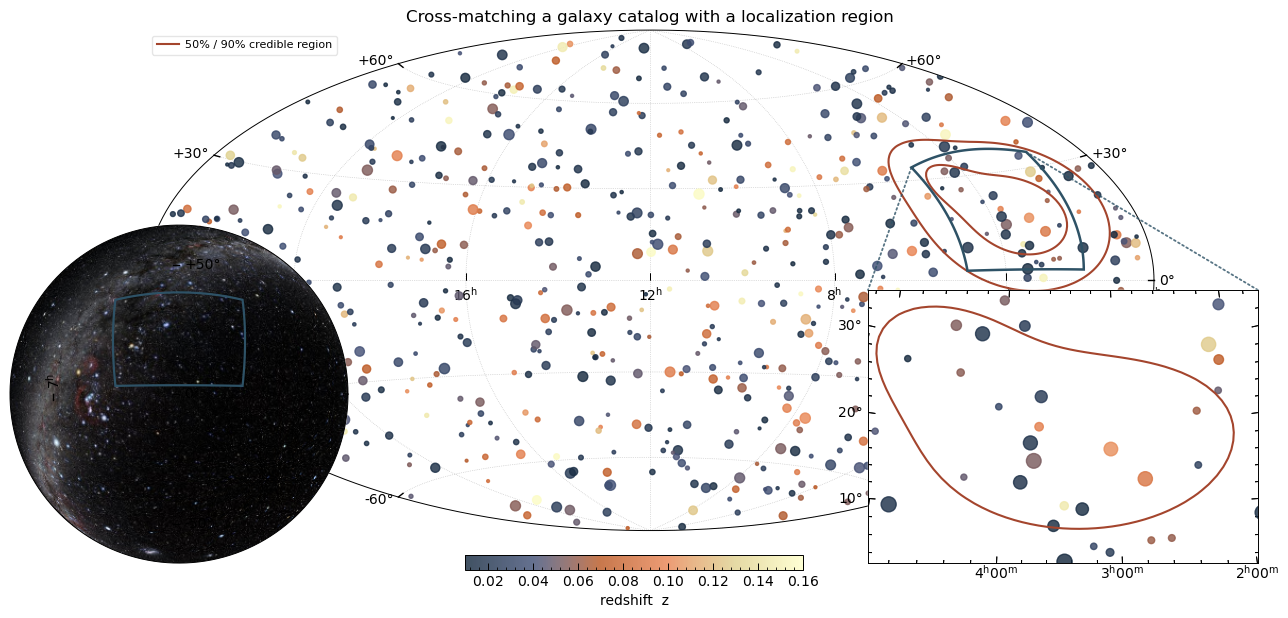

In [13]:
# fig-slug: capstone
# A synthetic all-sky galaxy catalog (uniform on the sphere), plus a two-lobe
# localization whose 50/90% credible contours we cross-match against it.
_rng = np.random.default_rng(11)
n_gal = 700
gal = {"ra": _rng.uniform(0, 360, n_gal),
       "dec": np.degrees(np.arcsin(_rng.uniform(-1, 1, n_gal))),
       "z": 10 ** _rng.uniform(-2.0, -0.8, n_gal),       # redshift ~0.01–0.16
       "bright": 10 ** _rng.uniform(0, 2, n_gal)}         # a skewed "brightness"

RA = np.linspace(0, 360, 361)
DEC = np.linspace(-90, 90, 181)
gra, gdec = np.meshgrid(RA, DEC)


def _blob(r0, d0, sr, sd, amp):
    dra = ((gra - r0 + 180) % 360 - 180) * np.cos(np.radians(gdec))
    return amp * np.exp(-0.5 * ((dra / sr) ** 2 + ((gdec - d0) / sd) ** 2))


prob = _blob(50, 18, 17, 10, 1.0) + _blob(70, 30, 8, 6, 0.45)
prob /= prob.sum()
# Density thresholds enclosing 50% / 90% of the total probability (credible regions).
_flat = np.sort(prob.ravel())[::-1]
_cum = np.cumsum(_flat)
lvl50 = _flat[np.searchsorted(_cum, 0.5)]
lvl90 = _flat[np.searchsorted(_cum, 0.9)]

ROI_CENTER, ROI_SIZE = (52, 20), (46, 34)
# Decoration colors from the active theme's annotation palette: `accent`
# delineates the credible region, `accent2` marks + connects the zoom. Both stay
# on-theme in light and dark modes. The galaxy scatter uses the bundled
# `sph.dusk` colormap (with a touch of transparency) to sit in the same palette.
PAL = theme_palette()
REGION, MARK = PAL["accent"], PAL["accent2"]


def draw_science(target, smin, smax):
    """The science layer — the galaxy catalog (size by brightness, color by
    redshift) with the credible-region contours over it — drawn identically on the
    main map and the zoom, so the zoom truly reproduces the wide view."""
    sc = sph.plot_catalog(target, gal, sizeby="bright", colorby="z", cmap="sph.dusk",
                          size_scale="sqrt", smin=smin, smax=smax,
                          vmin=0.01, vmax=0.16, alpha=0.82)
    sph.add_contour_overlay(target, gra, gdec, prob, levels=[lvl90, lvl50],
                            colors=REGION, linewidths=1.5)
    return sc


fig = plt.figure(figsize=(13, 6.5))
ax = sph.make_wcs_frame(111, projection="AIT", center=180, frame="ICRS", fig=fig)
ax.set_title("Cross-matching a galaxy catalog with a localization region", fontsize=12)
sc = draw_science(ax, smin=4, smax=55)
# Colorbar on an explicit horizontal cax along the bottom, clear of the insets in
# the lower corners (the auto 'inset' placement collides with the zoom).
cax = fig.add_axes([0.37, 0.05, 0.26, 0.022])
sph.add_colorbar(sc, cax=cax, orientation="horizontal", label="redshift  z")
ax.legend(handles=[Line2D([0], [0], color=REGION, lw=1.5,
                          label="50% / 90% credible region")],
          loc="upper left", fontsize=8, framealpha=0.5)

# Zoom into the high-probability region — same catalog + contours, up close. The
# dusk colormap already carries blues, so we give the zoom a near-black (dark mode)
# / white (light mode) card rather than the bluish default, to keep the points crisp.
zoom_bg = "#0a0b0e" if _dark_mode() else "#ffffff"
zoom = sph.reproject_inset_axes(
    ax, rect=[0.68, 0.06, 0.30, 0.42], transform="figure",
    projection="TAN", center=ROI_CENTER, size=ROI_SIZE, bg_color=zoom_bg)
draw_science(zoom, smin=18, smax=120)
clean_inset(zoom)
sph.mark_inset_axes(ax, zoom, edgecolor=MARK, linewidth=1.8)
sph.connect_inset_axes(ax, zoom, color=MARK, linewidth=1.3, corners=[('ul','ul'),('ur','ur')])

# A globe of the actual night sky for context, with the same region marked (no
# connectors needed — it's an orientation aid, not a zoom).
globe = sph.reproject_inset_axes(
    ax, rect=[0.02, 0.06, 0.26, 0.52], transform="figure",
    projection="SIN", center=(ROI_CENTER[0], 0), size=180,
    frame_class=EllipticalFrame)
globe.imshow(sph.reproject_background(panorama, pano_hdr, globe),
             origin="lower")
for c in (0, 1):                       # light labels read over the panorama
    globe.coords[c].set_ticklabel(color="0.9")
sph.mark_inset_axes(globe, zoom, edgecolor=MARK, linewidth=1.6)
plt.show()

## 8. Where to go next

| If you want to… | Go to |
| --- | --- |
| Add beams, scale bars, a compass rose, rulers or reticles to a zoomed figure | **Annotations and Overlays** |
| Draw the *region* an inset marks as a footprint or polygon | **Regions and Spherical Polygons** |
| Stretch, colorbar, or contour the image inside an inset | [FITS Images and Quicklook](fits_images.ipynb) |
| Choose the projection for a globe-style or all-sky inset | [A Tour of Projections](projections.ipynb) |
| Style the ticks, grid and labels of an inset frame | [Decorating Frames](decorating_frames.ipynb) |

The inset machinery is documented in the [overlays guide](../guide/overlays.md)
and the [globe guide](../guide/globe.md).